**15.4. Project 4. House Price Prediction**

**Dataset:** California Housing Prices - `housing.csv`

**Kaggle link:** https://www.kaggle.com/datasets/camnugent/california-housing-prices

> Process: EDA → preprocessing → baseline model → model selection (CV) → tuning (GridSearchCV) → final evaluation → inference.


**1. Setup**

In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [ ]:
# configurations
pd.set_option("display.max_columns", None) # por padrão o pandas, quando o dataset tem muitas colunas ele n mostra algumas, aqui eu to pedindo que ele mostre todas 
pd.set_option("display.float_format", lambda x: f"{x:.3f}") # aqui eu to formatando o nome de decimais quando determinado atributo for float 
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "housing.csv"          
TARGET_COL = "median_house_value" # target column name

**2. Load Data**

In [4]:
df = pd.read_csv(CSV_PATH)

In [5]:
print("DataFrame shape:", df.shape)

DataFrame shape: (20640, 10)


In [6]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


**3. Exploratory Data Analysis (EDA)**

In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

**Column details:**

1. Longitude : Medida da distância de uma casa para oeste; um valor maior indica uma localização mais a oeste.

2. Latitude : Medida da distância de uma casa para norte; um valor maior indica uma localização mais ao norte .

3. IdadeMedianaDasCasas : Idade mediana das casas em um quarteirão; um número menor indica uma construção mais nova.

4. TotalDeQuartos : Número total de quartos em um quarteirão

5. TotalDeQuartos : Número total de quartos em um quarteirão

6. População : Número total de pessoas que residem em um quarteirão

7. Domicílios : Número total de domicílios, ou seja, grupos de pessoas que residem em uma mesma unidade habitacional, em um quarteirão

8. RendaMediana : Renda mediana dos domicílios em um quarteirão (medida em dezenas de milhares de dólares americanos).

9. ValorMedianoDosDomicílios : Valor mediano dos domicílios em um quarteirão (medido em dólares americanos).

10. ProximidadeDoOceano : Localização da casa em relação ao oceano/mar.

In [9]:
# basic dataset overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['str']).columns.tolist()

print("Target column:", TARGET_COL)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Target column: median_house_value
Numerical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns: ['ocean_proximity']


In [ ]:
# missing values analysis
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [11]:
# check presence of encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(20))

longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.370    128
-118.250    128
-118.200    126
-118.140    125
-118.130    121
-118.260    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
34.110    162
33.980    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20.000     465
29.000     461
Name: coun

**NOTE: total_bedrooms has missing values**

In [12]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0


In [13]:
# descriptive stat
df[num_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000,20640.000,20640.000,20640.000,20433.000,20640.000,20640.000,20640.000,20640.000
mean,-119.570,35.632,28.639,2635.763,537.871,1425.477,499.540,3.871,206855.817
std,2.004,2.136,12.586,2181.615,421.385,1132.462,382.330,1.900,115395.616
min,-124.350,32.540,1.000,2.000,1.000,3.000,1.000,0.500,14999.000
25%,-121.800,33.930,18.000,1447.750,296.000,787.000,280.000,2.563,119600.000
50%,-118.490,34.260,29.000,2127.000,435.000,1166.000,409.000,3.535,179700.000
75%,-118.010,37.710,37.000,3148.000,647.000,1725.000,605.000,4.743,264725.000
max,-114.310,41.950,52.000,39320.000,6445.000,35682.000,6082.000,15.000,500001.000


In [14]:
# descriptive stat
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


**Data Visualization**

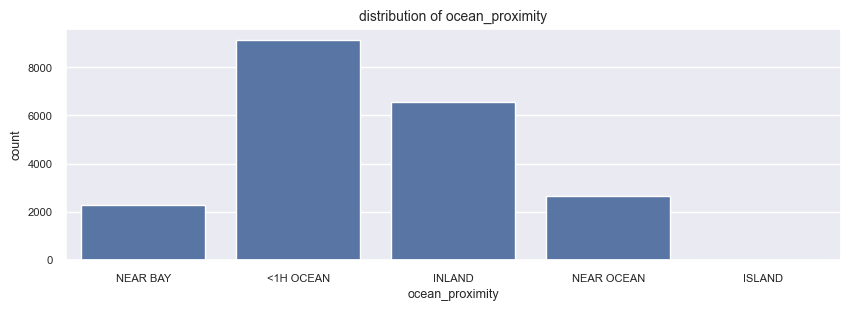

In [27]:
# countplot for categorical columns
for col in cat_cols:
    plt.figure(figsize=(10, 3))
    sns.countplot(x=col, data=df)
    plt.title(f"distribution of {col}")
    plt.show()


In [17]:
for col in cat_cols:
    print(df[col].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


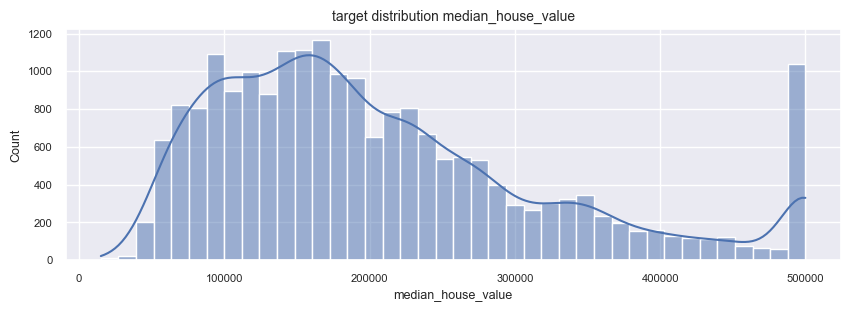

In [ ]:
# target column distribution
plt.figure(figsize=(10, 3))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title(f"target distribution {TARGET_COL}")
plt.xlabel(TARGET_COL)
plt.show()

#olhando para esse gráfico percebi que eles estão fazendo um upper cap 

In [24]:
df[TARGET_COL].value_counts()
# higher cap

median_house_value
500001.000    965
137500.000    122
162500.000    117
112500.000    103
187500.000     93
             ... 
422900.000      1
349400.000      1
425800.000      1
200700.000      1
47000.000       1
Name: count, Length: 3842, dtype: int64

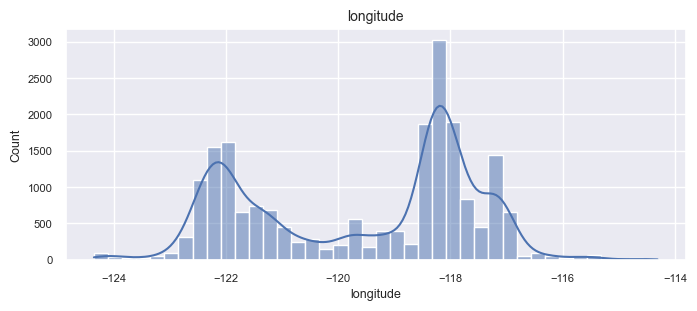

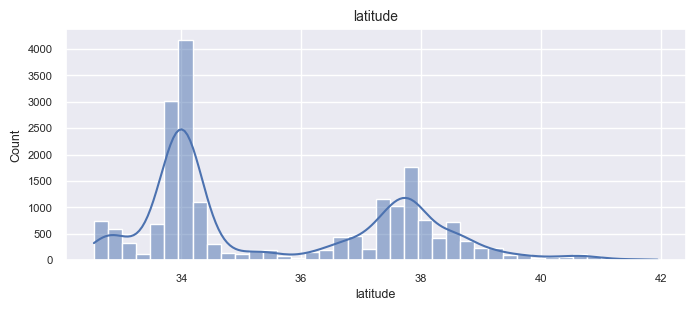

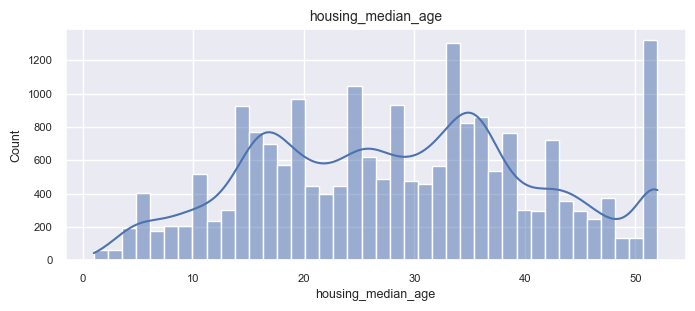

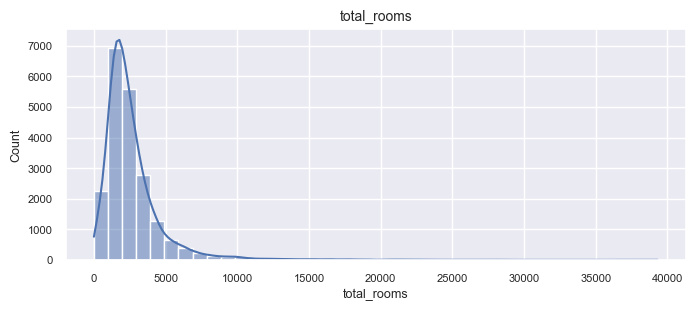

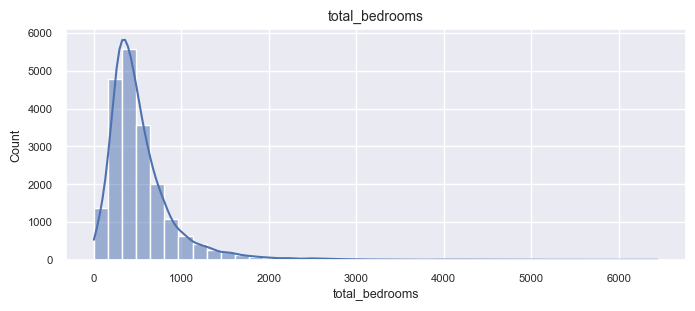

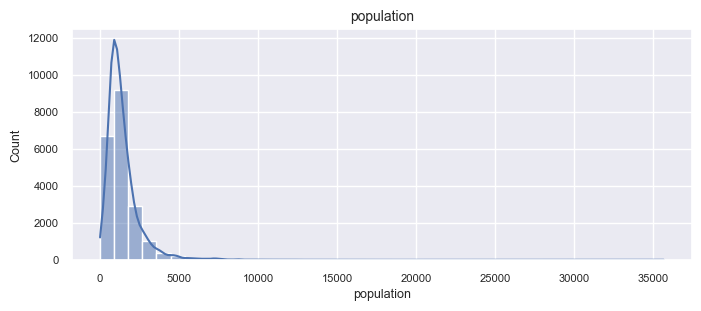

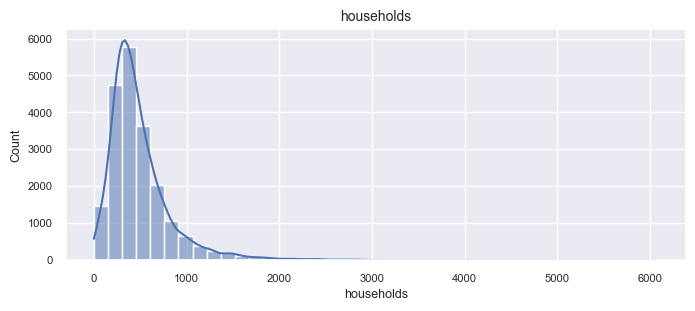

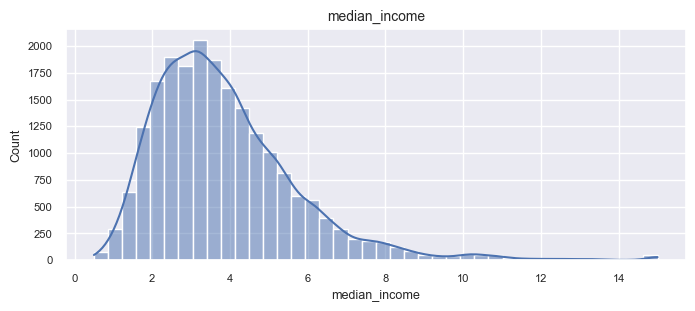

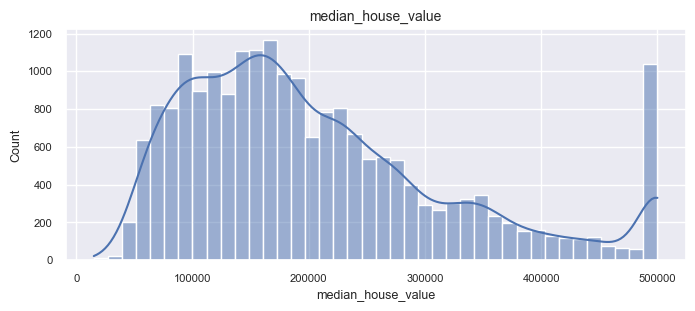

In [ ]:
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(col)
    plt.xlabel(col)
    plt.show()

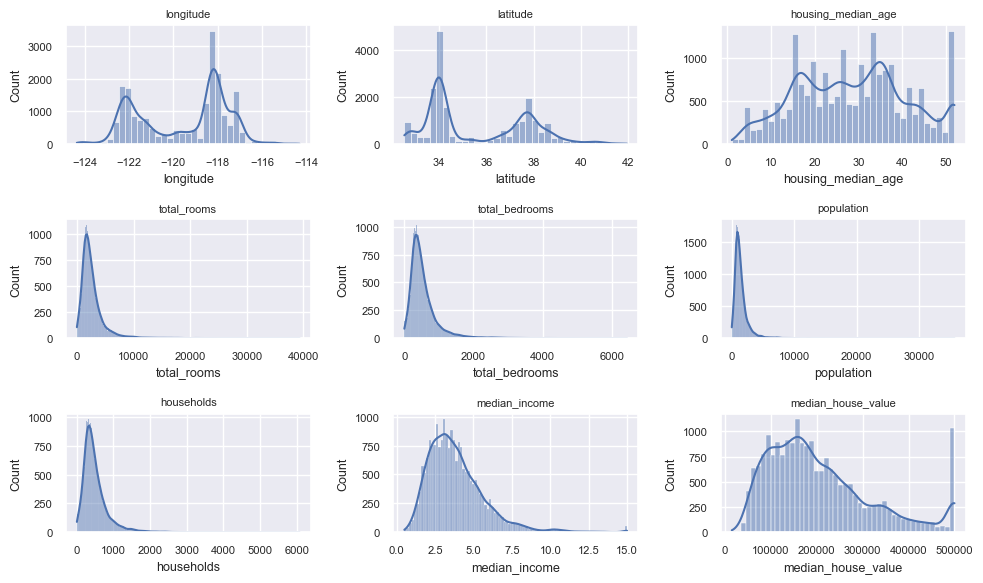

In [34]:
# histogram plot - distribution
fig, axes = plt.subplots(3, 3, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

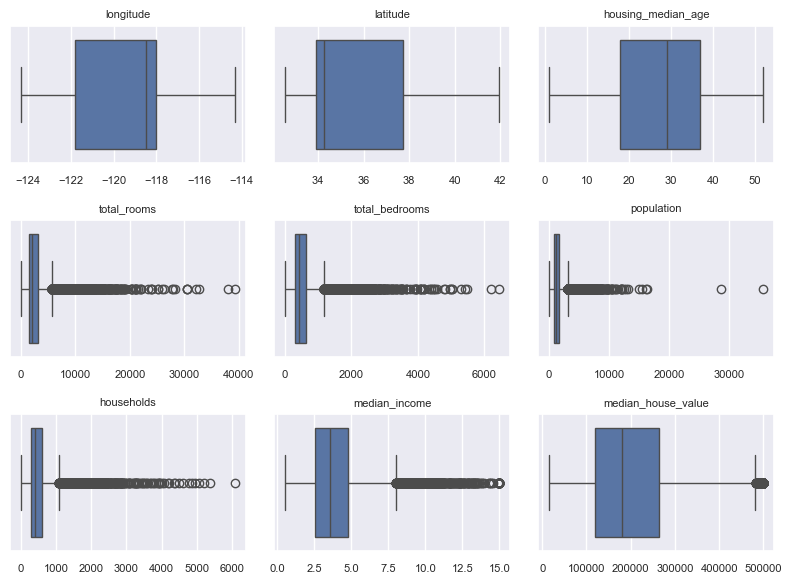

In [35]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

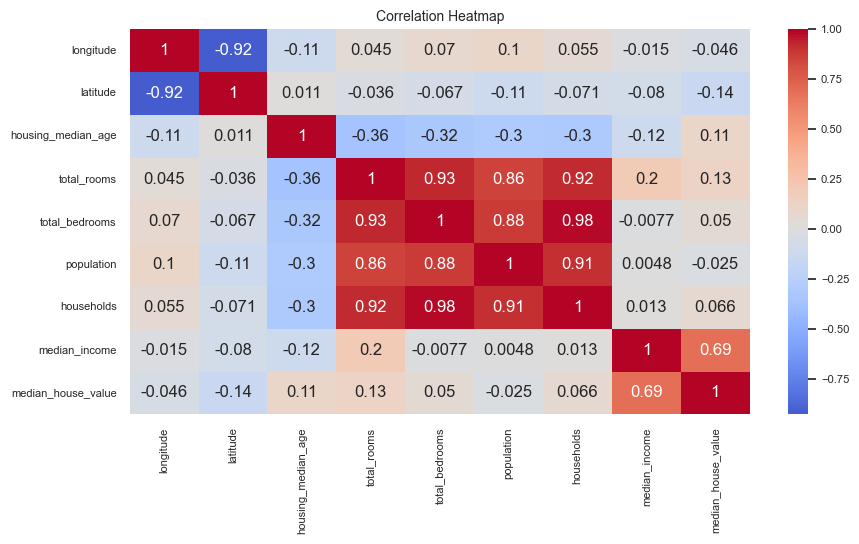

In [40]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [22]:
# Correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)


Correlation with target:
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


---

🔍 Key Insights from EDA
- Dataset has numeric + one categorical feature (ocean_proximity)
- Only total_bedrooms has missing values
- Target (median_house_value) is right-skewed and capped
- Several features show strong skew and outliers
- median_income is the strongest predictor
- High multicollinearity among room and population features

⸻

🛠️ Preprocessing & Evaluation Plan
- Median imputation for missing values
- One-hot encoding for categorical feature
- Feature scaling for linear models
- Use pipelines to avoid data leakage
- Baseline model → CV model selection → hyperparameter tuning
- Primary metric: RMSE, secondary: MAE and R²
- Final evaluation only on test set


---

**4. Data Preprocessing**

In [41]:
#separete features and target

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [42]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY


In [43]:
y.head()

0   452600.000
1   358500.000
2   352100.000
3   341300.000
4   342200.000
Name: median_house_value, dtype: float64

In [44]:
# train test split 

X_train, X_test, y_train, y_test =  train_test_split(
    X, 
    y, 
    test_size=0.2,
    random_state=RANDOM_STATE #20% becomes test data
)

In [45]:
print("train shape: ", X_train.shape)
print("test shape: ", X_test.shape)

train shape:  (16512, 9)
test shape:  (4128, 9)


**Preprocessing Pipeline**

In [ ]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("numerical_features: ", numerical_features)
print("categorical_features: ", categorical_features)


#numerical features - preporcessing steps 
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())   
           ]
)

#categorical features - preprocessing steps 

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))  
           ]
)

#preprocessing pipeline 

preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

numerical_features:  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
categorical_features:  ['ocean_proximity']


**5. Baseline model (No CV, No Tuning)**

In [52]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
        
        ]
    )

In [53]:
baseline_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

**Evaluation of baseline model**

In [ ]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [55]:
train_baseline_pred[:5]

array([188628.07724361, 290379.8948687 , 250985.48476349, 146878.07878194,
       165789.41368924])

In [56]:
y_train[:5]

14196   103000.000
8267    382100.000
17445   172600.000
14265    93400.000
2271     96500.000
Name: median_house_value, dtype: float64

In [ ]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)


print("\n== TRAIN BASELINE METRICS (LINEAR REGRESSION) ==")
print(f"RSME: {train_baseline_rmse:.3f}") #Mede o erro médio, mas penaliza mais erros grandes
print(f"MAE: {train_baseline_mae:.3f}") #Média do erro absoluto
print(f"R2: {train_baseline_r2:.3f}") #Mede o quanto o modelo explica os dados


== TRAIN BASELINE METRICS (LINEAR REGRESSION) ==
RSME: 68433.937
MAE: 49594.842
R2: 0.650


In [59]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n=== TEST BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE : {test_baseline_mae:.3f}")
print(f"R2  : {test_baseline_r2:.3f}")


=== TEST BASELINE METRICS (LinearRegression) ===
RMSE: 70059.193
MAE : 50670.489
R2  : 0.625


**6. Model Selection & Optimization**

**BEST MODEL: HistGradientBoostingRegressor**

**7. Hyperparameter Tuning**

**8. Retraining with best params**

**9. Final Evaluation**

**10. Building a predictive system**


Example prediction: 460493.28


**📈 Ways to improve performance**

- Create ratio features
    - rooms_per_household
    - bedrooms_per_room
    - population_per_household
- Try log transformation on the target variable.
- Tune max_iter and max_bins for HistGradientBoosting.
- Try advanced boosting models like XGBoost or LightGBM.
- Do error analysis by location or price ranges instead of only metrics.
- Use spatial or grouped validation for location-based data.